In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    BaggingClassifier
)

from xgboost import XGBClassifier

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout

In [ ]:

from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [ ]:

import zipfile

with zipfile.ZipFile('archive (2).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("ZIP Extracted Successfully!")

ZIP Extracted Successfully!


In [ ]:
import os

os.listdir('/content/')

['.config', 'laptop_dataset_final.csv', 'archive (2).zip', 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv('laptop_dataset_final.csv')

df.head()

/tmp/ipykernel_2568/830892881.py:3: DtypeWarning: Columns (17,22,23,26,35,43,55,57,58,59,61,62,63,66,69,70,72,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('laptop_dataset_final.csv')


,Brand,Model,Series,Thickness,Dimensions (WxDxH),Weight,Colors,Operating System,Operating System Type,Display Size,...,Lockport,Battery Life,USB Type C,Battery Capacity,Aspect Ratio,Number of Cores,SSD Interface,Fast Charging Support,market_status,Price (Rs)
0,HP,14-dv0055TU (2N1L1PA),Pavilion,17 Millimeter thickness,325 x 216 x 17 mm,1.41 Kg weight (Light-weight),Tranquil Pink,Windows 10 Home Basic,64-bit,14 Inches (35.56 cm),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Available,71990.0
1,Acer,PHN16-71 (NH.QLTSI.002),Predator Helios Neo 16,26.5 Millimeter thickness,361 x 279 x 26.5 mm,2.6 Kg weight,Black,Windows 11 Home Basic,NaN,16 Inches (40.64 cm),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Available,105999.0
2,Dell,15 5570 (A560126WIN9),Inspiron 15,22.7 Millimeter thickness,380 x 258 x 22.7 mm,2.2 Kg weight,Platinum Silver,Windows 10 Home Basic,64-bit,15.6 Inches (39.62 cm),...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Available,54999.0
3,MSI,GV62 7RD-2297XIN,NaN,29 Millimeter thickness,383 x 260 x 29 mm,2.2 Kg weight,Black,DOS,64-bit,15.6 Inches (39.62 cm),...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Available,67990.0
4,Dell,15 3515 (D560702WIN9BE),Inspiron 15,23 Millimeter thickness,358.50 x 17.50 x 23 mm,1.8 Kg weight,"Carbon Black, Platinum Silver",Windows 11 Home Basic,64-bit,15.6 Inches (39.62 cm),...,NaN,7 Hrs,2.0,NaN,NaN,NaN,NaN,NaN,Available,42210.0


In [ ]:
print(df.shape)
print(df.info())
print(df.describe())

(8198, 76)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8198 entries, 0 to 8197
Data columns (total 76 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Brand                       8198 non-null   object 
 1   Model                       8198 non-null   object 
 2   Series                      7105 non-null   object 
 3   Thickness                   7518 non-null   object 
 4   Dimensions (WxDxH)          7516 non-null   object 
 5   Weight                      7891 non-null   object 
 6   Colors                      8022 non-null   object 
 7   Operating System            8198 non-null   object 
 8   Operating System Type       4678 non-null   object 
 9   Display Size                8195 non-null   object 
 10  Display Resolution          8166 non-null   object 
 11  Pixel Density               8164 non-null   object 
 12  Display Type                4308 non-null   object 
 13  Display Features      

In [ ]:
print(df.isnull().sum())

df.fillna(df.mean(numeric_only=True), inplace=True)

Brand                       0
Model                       0
Series                   1093
Thickness                 680
Dimensions (WxDxH)        682
                         ... 
Number of Cores          5273
SSD Interface            6145
Fast Charging Support    7258
market_status               0
Price (Rs)                 21
Length: 76, dtype: int64


In [ ]:
print("Mean")
print(df.mean(numeric_only=True))

print("Median")
print(df.median(numeric_only=True))

print("Mode")
print(df.mode().iloc[0])

Mean
Wi-Fi Version            5.454702
Bluetooth Version        4.859404
USB 2.0 slots            1.328062
Ethernet ports           1.000581
USB 3.0 slots            1.692308
USB Type C               1.216336
Number of Cores          8.917607
Price (Rs)           80852.045738
dtype: float64
Median
Wi-Fi Version            5.454702
Bluetooth Version        5.000000
USB 2.0 slots            1.328062
Ethernet ports           1.000581
USB 3.0 slots            1.692308
USB Type C               1.000000
Number of Cores          8.917607
Price (Rs)           64990.000000
dtype: float64
Mode
Brand                                         Asus
Model                          INBook X1 Slim XL21
Series                                     Ideapad
Thickness                19.9 Millimeter thickness
Dimensions (WxDxH)          357.9 x 255 x 23.5  mm
                                   ...            
Number of Cores                           8.917607
SSD Interface                            NVMe PCIe
F

In [ ]:
print(df.columns)

Index(['Brand', 'Model', 'Series', 'Thickness', 'Dimensions (WxDxH)', 'Weight',
       'Colors', 'Operating System', 'Operating System Type', 'Display Size',
       'Display Resolution', 'Pixel Density', 'Display Type',
       'Display Features', 'Display Touchscreen', 'Processor', 'Clock-speed',
       'Chipset', 'Cache', 'Graphic Processor', 'Capacity', 'RAM Type',
       'RAM Speed', 'Memory Slots', 'Memory Layout', 'SSD Capacity',
       'SSD Type', 'Battery Cell', 'Battery Type', 'Power Supply',
       'Wireless LAN', 'Wi-Fi Version', 'Bluetooth', 'Bluetooth Version',
       'Other Networking Options', 'HDMI Ports', 'USB 2.0 slots',
       'SD Card Reader', 'Ethernet ports', 'Headphone Jack', 'Microphone Jack',
       'Web-cam', 'Video Recording', 'Audio Solution', 'Speakers',
       'Sound Technologies', 'In-built Microphone', 'Microphone Type',
       'Pointing device', 'Keyboard', 'Fingerprint scanner',
       'Face Recognition', 'Warranty', 'Sales Package', 'Refresh Rate',
   

In [ ]:
df['Capacity'].value_counts(normalize=True)

,proportion
Capacity,
8 GB,0.403757
16 GB,0.381800
4 GB,0.141376
32 GB,0.051720
24 GB,0.006953
2 GB,0.004635
64 GB,0.003781
12 GB,0.002684
36 GB,0.001220


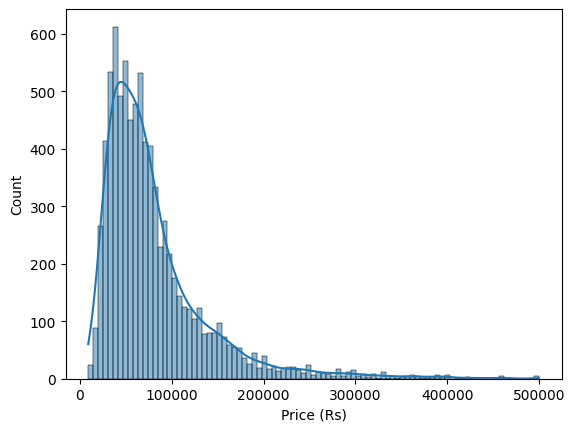

In [ ]:
sns.histplot(df['Price (Rs)'], kde=True)
plt.show()

In [ ]:
print(df['Price (Rs)'].skew())

2.418338580376129


In [ ]:
print("Range:", df['Price (Rs)'].max() - df['Price (Rs)'].min())

print("Variance:", df['Price (Rs)'].var())

print("Standard Deviation:", df['Price (Rs)'].std())

Range: 491000.0
Variance: 3518169943.4335766
Standard Deviation: 59314.163093089126


In [ ]:
Q1 = df['Price (Rs)'].quantile(0.25)

Q3 = df['Price (Rs)'].quantile(0.75)

IQR = Q3 - Q1

print(Q1, Q3, IQR)

42499.0 96990.0 54491.0


In [ ]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Price (Rs)'] < lower) |
    (df['Price (Rs)'] > upper)
]

print(outliers)

       Brand                           Model             Series  \
122    Apple                       MWP52HN/A        MacBook Pro   
217     Asus                     G533QS-DS94  ROG Strix Scar 15   
275       HP           17-cb0090nr (7FT35UA)               Omen   
285     Asus                  G533QS-HF059TS  ROG Strix Scar 15   
288     Asus                  G533QS-HF210TS  ROG Strix Scar 15   
...      ...                             ...                ...   
8119      HP            17-an110nr (3WE36UA)               Omen   
8147  Lenovo                P53 (20QQS0JD0C)           Thinkpad   
8192    Acer  7 Pro CN715-71P (NX.C4PSI.002)           ConceptD   
8193    Acer  7 CN715-71-756Q (NX.C4KSI.007)           ConceptD   
8194    Acer  7 CN715-71-756Q (NX.C4KSI.003)           ConceptD   

                             Thickness        Dimensions (WxDxH)  \
122   15.6 Millimeter thickness (Slim)  304.1 x 212.4 x 15.6  mm   
217          27.2 Millimeter thickness  354.1 x 259.1 x 27.

In [ ]:
df = df[
    (df['Price (Rs)'] >= lower) &
    (df['Price (Rs)'] <= upper)
]

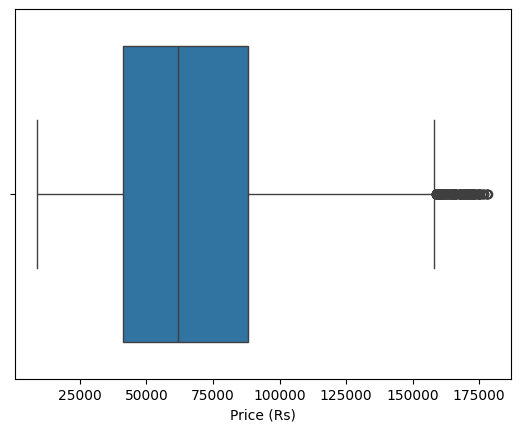

In [ ]:
sns.boxplot(x=df['Price (Rs)'])
plt.show()

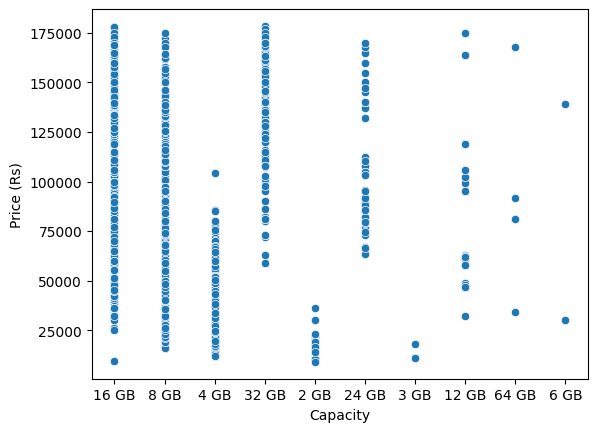

In [ ]:
sns.scatterplot(
    x=df['Capacity'],
    y=df['Price (Rs)']
)

plt.show()

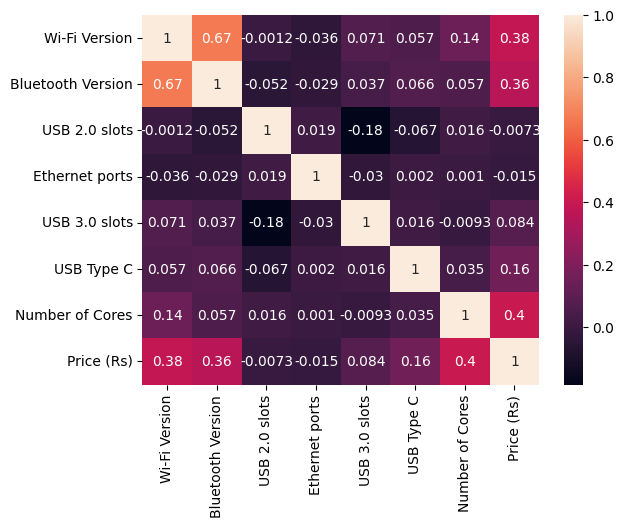

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

In [ ]:
brand_scores = {
    'Apple': 5,
    'Dell': 4,
    'HP': 3,
    'Lenovo': 3,
    'Asus': 3,
    'Acer': 2,
    'MSI': 4,
    'Razer': 5,
    'Samsung': 4,
    'Toshiba': 2,
    'Huawei': 3,
    'Xiaomi': 3,
    'LG': 4
}

df['Brand_Value_Score'] = df['Brand'].map(brand_scores)

df['Brand_Value_Score'] = df['Brand_Value_Score'].fillna(3)

print(df[['Brand', 'Brand_Value_Score']].head())

   Brand  Brand_Value_Score
0      9                3.0
1      0                3.0
2      6                3.0
3     16                3.0
4      6                3.0


In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

/tmp/ipykernel_2568/2464828497.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col].astype(str))
/tmp/ipykernel_2568/2464828497.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col].astype(str))
/tmp/ipykernel_2568/2464828497.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

In [ ]:
print(df[['Brand_Value_Score']].head())

   Brand_Value_Score
0                3.0
1                3.0
2                3.0
3                3.0
4                3.0


In [ ]:
X = df.drop('Price (Rs)', axis=1)
y = df['Price (Rs)']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# target creation
df['Price_Category'] = pd.qcut(df['Price (Rs)'], q=3, labels=[0,1,2])

# split
X = df.drop(['Price (Rs)', 'Price_Category'], axis=1)
y = df['Price_Category']

# convert categorical columns to numeric
X = pd.get_dummies(X, drop_first=True)

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model
log = LogisticRegression(max_iter=500)

log.fit(X_train, y_train)

# prediction
pred = log.predict(X_test)

print(accuracy_score(y_test, pred))

/tmp/ipykernel_2568/1070753146.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price_Category'] = pd.qcut(df['Price (Rs)'], q=3, labels=[0,1,2])


0.6853055916775033


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
dt = DecisionTreeClassifier(criterion='gini', max_depth=5)

dt.fit(X_train, y_train)

pred = dt.predict(X_test)

print(accuracy_score(y_test, pred))

0.7457737321196359


In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Bagging": BaggingClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc

print(results)

{'Decision Tree': 0.758777633289987, 'Bagging': 0.812743823146944, 'Random Forest': 0.8426527958387516, 'AdaBoost': 0.7854356306892067, 'Gradient Boosting': 0.8478543563068921, 'XGBoost': 0.85370611183355}


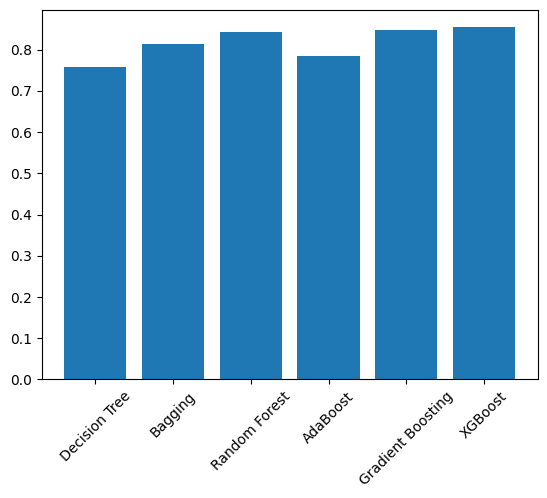

In [ ]:
plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv("laptop_dataset_final.csv")

/tmp/ipykernel_5967/2490037871.py:3: DtypeWarning: Columns (17,22,23,26,35,43,55,57,58,59,61,62,63,66,69,70,72,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("laptop_dataset_final.csv")


In [ ]:
df = df.dropna(subset=['Price (Rs)'])

In [ ]:
df = df.dropna(subset=['Price (Rs)'])
df = df.dropna()

In [ ]:
df = df.dropna(subset=['Price (Rs)']).copy()

df['Price_Category'] = pd.qcut(
    df['Price (Rs)'],
    q=3,
    labels=False,
    duplicates='drop'
)

In [ ]:
df = df.dropna()

In [ ]:
df = df.dropna().copy()

In [ ]:
import pandas as pd

df = pd.read_csv("your_file.csv")

(0, 77)
0


In [ ]:
import pandas as pd

df = pd.read_csv('laptop_dataset_final.csv')

df.head()

/tmp/ipykernel_5967/830892881.py:3: DtypeWarning: Columns (17,22,23,26,35,43,55,57,58,59,61,62,63,66,69,70,72,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('laptop_dataset_final.csv')


,Brand,Model,Series,Thickness,Dimensions (WxDxH),Weight,Colors,Operating System,Operating System Type,Display Size,...,Lockport,Battery Life,USB Type C,Battery Capacity,Aspect Ratio,Number of Cores,SSD Interface,Fast Charging Support,market_status,Price (Rs)
0,HP,14-dv0055TU (2N1L1PA),Pavilion,17 Millimeter thickness,325 x 216 x 17 mm,1.41 Kg weight (Light-weight),Tranquil Pink,Windows 10 Home Basic,64-bit,14 Inches (35.56 cm),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Available,71990.0
1,Acer,PHN16-71 (NH.QLTSI.002),Predator Helios Neo 16,26.5 Millimeter thickness,361 x 279 x 26.5 mm,2.6 Kg weight,Black,Windows 11 Home Basic,NaN,16 Inches (40.64 cm),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Available,105999.0
2,Dell,15 5570 (A560126WIN9),Inspiron 15,22.7 Millimeter thickness,380 x 258 x 22.7 mm,2.2 Kg weight,Platinum Silver,Windows 10 Home Basic,64-bit,15.6 Inches (39.62 cm),...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Available,54999.0
3,MSI,GV62 7RD-2297XIN,NaN,29 Millimeter thickness,383 x 260 x 29 mm,2.2 Kg weight,Black,DOS,64-bit,15.6 Inches (39.62 cm),...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Available,67990.0
4,Dell,15 3515 (D560702WIN9BE),Inspiron 15,23 Millimeter thickness,358.50 x 17.50 x 23 mm,1.8 Kg weight,"Carbon Black, Platinum Silver",Windows 11 Home Basic,64-bit,15.6 Inches (39.62 cm),...,NaN,7 Hrs,2.0,NaN,NaN,NaN,NaN,NaN,Available,42210.0


In [ ]:
print(df.shape)

(8198, 76)


In [ ]:
df = df.copy()

df['Price_Category'] = pd.cut(
    df['Price (Rs)'],
    bins=3,
    labels=[0,1,2]
)

In [ ]:
X = df.drop(['Price (Rs)', 'Price_Category'], axis=1)
y = df['Price_Category']

X = pd.get_dummies(X, drop_first=True)

In [ ]:
X = X.fillna(0)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X.isna().sum().sum())

0


In [ ]:
X = X.fillna(0)

In [ ]:
# 1. features & target
X = df.drop(['Price (Rs)', 'Price_Category'], axis=1)
y = df['Price_Category']

# 2. convert text columns to numbers
X = pd.get_dummies(X, drop_first=True)

# 3. HANDLE MISSING VALUES (THIS LINE)
X = X.fillna(0)

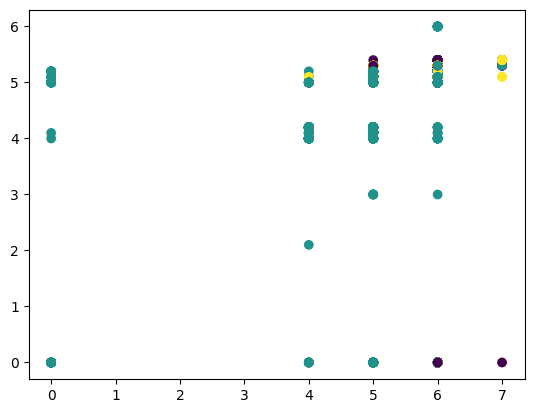

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X)

plt.scatter(X.iloc[:,0], X.iloc[:,1], c=clusters)
plt.show()

/tmp/ipykernel_10038/1007774164.py:8: DtypeWarning: Columns (17,22,23,26,35,43,55,57,58,59,61,62,63,66,69,70,72,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("laptop_dataset_final.csv")


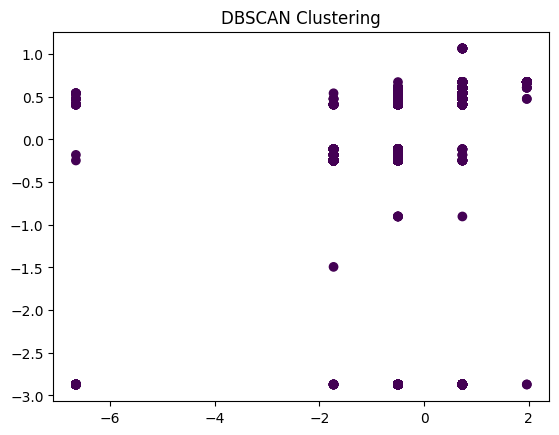

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN


df = pd.read_csv("laptop_dataset_final.csv")

df = df.dropna(subset=['Price (Rs)']).copy()

X = df.drop(['Price (Rs)'], axis=1)


X = pd.get_dummies(X, drop_first=True)

X = X.fillna(0)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

db = DBSCAN(eps=0.5, min_samples=5)
clusters = db.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters)
plt.title("DBSCAN Clustering")
plt.show()

/tmp/ipykernel_10881/2765218319.py:6: DtypeWarning: Columns (17,22,23,26,35,43,55,57,58,59,61,62,63,66,69,70,72,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("laptop_dataset_final.csv")


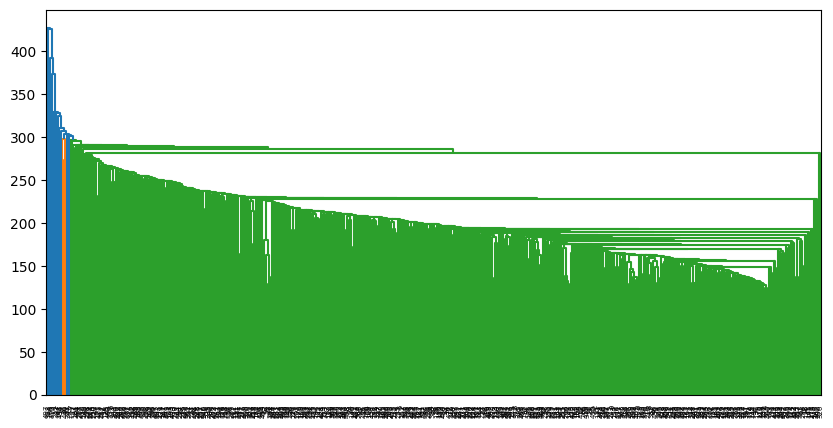

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram

df = pd.read_csv("laptop_dataset_final.csv")
df = df.dropna(subset=['Price (Rs)']).copy()

X = df.drop(['Price (Rs)'], axis=1)
X = pd.get_dummies(X, drop_first=True)
X = X.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_sample = pd.DataFrame(X_scaled).sample(500, random_state=42)

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("laptop_dataset_final.csv")

df = df.dropna(subset=['Price (Rs)']).copy()

df['Price_Category'] = pd.cut(
    df['Price (Rs)'],
    bins=3,
    labels=[0,1,2]
)

df = df.dropna(subset=['Price_Category'])

X = df.drop(['Price (Rs)', 'Price_Category'], axis=1)
y = df['Price_Category']

X = pd.get_dummies(X, drop_first=True)
X = X.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

/tmp/ipykernel_14642/104548251.py:5: DtypeWarning: Columns (17,22,23,26,35,43,55,57,58,59,61,62,63,66,69,70,72,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("laptop_dataset_final.csv")


(6541, 21126)


In [ ]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=20)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

svm = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    cache_size=500
)

svm.fit(X_train_pca, y_train)

pred = svm.predict(X_test_pca)

from sklearn.metrics import accuracy_score
print("SVM Accuracy:", accuracy_score(y_test, pred))

SVM Accuracy: 0.9535452322738386


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

random = RandomizedSearchCV(
    RandomForestClassifier(),
    params,
    n_iter=5,
    cv=3,
    n_jobs=-1,
    random_state=42
)

random.fit(X_train, y_train)

print(random.best_params_)
print(random.best_score_)

{'n_estimators': 50, 'min_samples_split': 5, 'max_depth': None}
0.9552057174345578


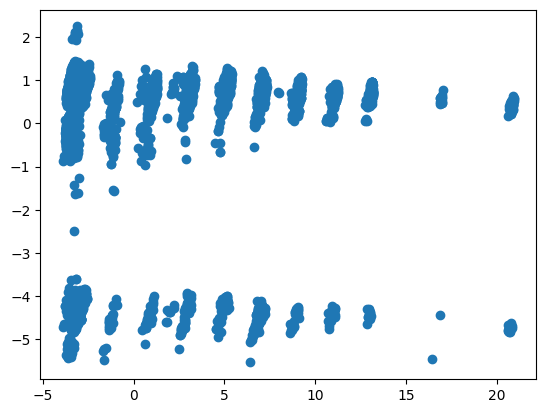

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# LOAD DATA
df = pd.read_csv("laptop_dataset_final.csv", low_memory=False)

# CLEAN MISSING PRICE VALUES
df = df.dropna(subset=['Price (Rs)'])

# TARGET CREATION
df['Price_Category'] = pd.qcut(df['Price (Rs)'], q=3, labels=[0,1,2])
df['Price_Category'] = df['Price_Category'].astype(int)

# FILL OTHER MISSING VALUES
df = df.fillna(0)

# ENCODE CATEGORICAL DATA
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# FEATURES & TARGET
X = df.drop(['Price (Rs)', 'Price_Category'], axis=1)
y = df['Price_Category']

# SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# SCALING
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# RESHAPE FOR CNN
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# CNN MODEL
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(64, 2, activation='relu', input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Conv1D(32, 2, activation='relu'),
    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TRAIN MODEL
model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# EVALUATE MODEL
loss, acc = model.evaluate(X_test, y_test)

print("CNN Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6378 - loss: 0.7644 - val_accuracy: 0.7235 - val_loss: 0.6231
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7550 - loss: 0.5589 - val_accuracy: 0.7594 - val_loss: 0.5396
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7873 - loss: 0.4952 - val_accuracy: 0.7762 - val_loss: 0.5127
Epoch 4/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8079 - loss: 0.4646 - val_accuracy: 0.7899 - val_loss: 0.4843
Epoch 5/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8236 - loss: 0.4238 - val_accuracy: 0.7937 - val_loss: 0.4941
Epoch 6/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8314 - loss: 0.4115 - val_accuracy: 0.7685 - val_loss: 0.5524
Epoch 7/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8408 - loss: 0.3899 - val_accuracy: 0.7991 - val_loss: 0.4984
Epoch 8/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8496 - loss: 0.3738 - val_accuracy:

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# LOAD DATA
df = pd.read_csv("laptop_dataset_final.csv", low_memory=False)

# CLEAN DATA
df = df.dropna(subset=['Price (Rs)'])

# TARGET
df['Price_Category'] = pd.qcut(df['Price (Rs)'], q=3, labels=[0,1,2])
df['Price_Category'] = df['Price_Category'].astype(int)

df = df.fillna(0)

# ENCODE CATEGORICAL
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# FEATURES
X = df.drop(['Price (Rs)', 'Price_Category'], axis=1)
y = df['Price_Category']

# SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# SCALE
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# RNN NEEDS 3D INPUT
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# RNN MODEL
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, activation='relu', input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TRAIN
model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# EVALUATE
loss, acc = model.evaluate(X_test, y_test)

print("RNN Accuracy:", acc)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.4694 - loss: 0.9936 - val_accuracy: 0.5646 - val_loss: 0.8691
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5917 - loss: 0.8392 - val_accuracy: 0.5775 - val_loss: 0.8585
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.6248 - loss: 0.7933 - val_accuracy: 0.6127 - val_loss: 0.8065
Epoch 4/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.6462 - loss: 0.7601 - val_accuracy: 0.6402 - val_loss: 0.7799
Epoch 5/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.6504 - loss: 0.7399 - val_accuracy: 0.6646 - val_loss: 0.7607
Epoch 6/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.6649 - loss: 0.7196 - val_accuracy: 0.6394 - val_loss: 0.7541
Epoch 7/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.6690 - loss: 0.7089 - val_accuracy: 0.6684 - val_loss: 0.7257
Epoch 8/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6869 - loss: 0.6883 - val_accuracy: 0.6746

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6834 - loss: 0.6937
Accuracy: 0.6833741068840027


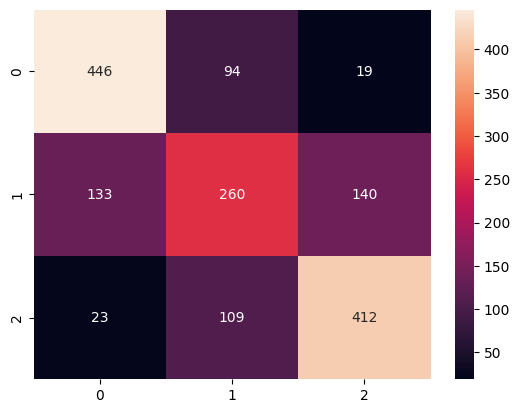

              precision    recall  f1-score   support

           0       0.74      0.80      0.77       559
           1       0.56      0.49      0.52       533
           2       0.72      0.76      0.74       544

    accuracy                           0.68      1636
   macro avg       0.67      0.68      0.68      1636
weighted avg       0.68      0.68      0.68      1636



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

print(classification_report(y_test, pred))


In [ ]:
brand_scores = {
    'Apple': 5,
    'Dell': 4,
    'HP': 3,
    'Lenovo': 3,
    'Asus': 3,
    'Acer': 2,
    'MSI': 4,
    'Razer': 5,
    'Samsung': 4,
    'Toshiba': 2,
    'Huawei': 3,
    'Xiaomi': 3,
    'LG': 4
}

df['Brand_Value_Score'] = df['Brand'].map(brand_scores)

df['Brand_Value_Score'] = df['Brand_Value_Score'].fillna(3)

In [ ]:
df[['Brand', 'Brand_Value_Score']].head()

,Brand,Brand_Value_Score
0,9,3.0
1,0,3.0
2,6,3.0
3,16,3.0
4,6,3.0
